# Exploratory Data Analysis 
EDA for predicting NCAA Division I Men's Basketball Tournament game outcomes, using the Kaggle *March Machine Learning Mania* dataset  

### Data used
1. Regular Season Detailed Results (`MRegularSeasonDetailedResults.csv`) - box-score level stats for every regular season game  
2. NCAA Tournament Compact Results (`MNCAATourneyCompactResults.csv`) - winner and looser of every tournament game

## Summary
This notebook serves as a broad data overview of the Kaggle data. All datasets, descriptions, and initial summaries can be found at the Kaggle page for the original competition. The goal here is to explore the broad trends within the selected data before any feature building or engineering.

### Import libraries and datasets

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

In [32]:
reg_season = pd.read_csv('data/raw/MRegularSeasonDetailedResults.csv')
tourney = pd.read_csv('data/raw/MNCAATourneyCompactResults.csv')

## Baseline Data Summaries

In [33]:
reg_season.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


In [34]:
tourney.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [35]:
reg_season.shape

(124529, 34)

In [36]:
tourney.shape

(2585, 8)

### Data quality and type

In [37]:
# checking the null values
reg_season.isnull().sum()

Season     0
DayNum     0
WTeamID    0
WScore     0
LTeamID    0
LScore     0
WLoc       0
NumOT      0
WFGM       0
WFGA       0
WFGM3      0
WFGA3      0
WFTM       0
WFTA       0
WOR        0
WDR        0
WAst       0
WTO        0
WStl       0
WBlk       0
WPF        0
LFGM       0
LFGA       0
LFGM3      0
LFGA3      0
LFTM       0
LFTA       0
LOR        0
LDR        0
LAst       0
LTO        0
LStl       0
LBlk       0
LPF        0
dtype: int64

In [60]:
# tournament results too
tourney.isnull().sum()

Season     0
DayNum     0
WTeamID    0
WScore     0
LTeamID    0
LScore     0
WLoc       0
NumOT      0
dtype: int64

In [38]:
# Check the dataframe information
reg_season.info()

<class 'pandas.DataFrame'>
RangeIndex: 124529 entries, 0 to 124528
Data columns (total 34 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Season   124529 non-null  int64
 1   DayNum   124529 non-null  int64
 2   WTeamID  124529 non-null  int64
 3   WScore   124529 non-null  int64
 4   LTeamID  124529 non-null  int64
 5   LScore   124529 non-null  int64
 6   WLoc     124529 non-null  str  
 7   NumOT    124529 non-null  int64
 8   WFGM     124529 non-null  int64
 9   WFGA     124529 non-null  int64
 10  WFGM3    124529 non-null  int64
 11  WFGA3    124529 non-null  int64
 12  WFTM     124529 non-null  int64
 13  WFTA     124529 non-null  int64
 14  WOR      124529 non-null  int64
 15  WDR      124529 non-null  int64
 16  WAst     124529 non-null  int64
 17  WTO      124529 non-null  int64
 18  WStl     124529 non-null  int64
 19  WBlk     124529 non-null  int64
 20  WPF      124529 non-null  int64
 21  LFGM     124529 non-null  int64
 22  LFGA   

### Statistical summary of both datasets

In [39]:
reg_season.describe()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,NumOT,WFGM,WFGA,WFGM3,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
count,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,...,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000,124529.000000
mean,2014.782717,70.596969,1288.567049,76.128540,1283.512226,64.127834,0.068562,26.483566,55.881554,7.409286,...,20.323820,12.131463,17.774799,10.365481,21.563885,11.441632,13.760273,6.006994,2.874182,19.245919
std,6.869123,36.029532,105.551098,11.046759,105.033483,10.883219,0.304346,4.687431,7.438681,3.143881,...,6.118137,5.361234,7.083072,4.207008,4.513894,3.733499,4.386113,2.742060,2.014910,4.550016
min,2003.000000,0.000000,1101.000000,34.000000,1101.000000,20.000000,0.000000,10.000000,26.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,2009.000000,40.000000,1199.000000,69.000000,1192.000000,57.000000,0.000000,23.000000,51.000000,5.000000,...,16.000000,8.000000,13.000000,7.000000,18.000000,9.000000,11.000000,4.000000,1.000000,16.000000
50%,2015.000000,74.000000,1287.000000,76.000000,1282.000000,64.000000,0.000000,26.000000,56.000000,7.000000,...,20.000000,12.000000,17.000000,10.000000,21.000000,11.000000,13.000000,6.000000,3.000000,19.000000
75%,2021.000000,102.000000,1382.000000,83.000000,1375.000000,71.000000,0.000000,29.000000,61.000000,9.000000,...,24.000000,15.000000,22.000000,13.000000,24.000000,14.000000,16.000000,8.000000,4.000000,22.000000
max,2026.000000,132.000000,1481.000000,149.000000,1481.000000,144.000000,6.000000,57.000000,103.000000,26.000000,...,59.000000,48.000000,65.000000,36.000000,49.000000,31.000000,41.000000,22.000000,18.000000,45.000000


In [ ]:
tourney.describe()

### Included seasons

In [40]:
print('Seasons:', reg_season['Season'].min(), '-', reg_season['Season'].max())
print('Total regular season games:', len(reg_season))

Seasons: 2003 - 2026
Total regular season games: 124529


### Games per season

In [41]:
# games played per season
reg_season.groupby('Season').size()

Season
2003    4616
2004    4571
2005    4675
2006    4757
2007    5043
2008    5163
2009    5249
2010    5263
2011    5246
2012    5253
2013    5320
2014    5362
2015    5354
2016    5369
2017    5395
2018    5405
2019    5463
2020    5328
2021    3855
2022    5345
2023    5602
2024    5607
2025    5641
2026    5647
dtype: int64

### Winning margin 
quick sense of how competitive regular season games are

In [42]:
reg_season['ScoreMargin'] = reg_season['WScore'] - reg_season['LScore']
reg_season['ScoreMargin'].describe()

count    124529.000000
mean         12.000707
std           9.258607
min           1.000000
25%           5.000000
50%          10.000000
75%          16.000000
max          94.000000
Name: ScoreMargin, dtype: float64

## Data Visualization

### Metric distributions

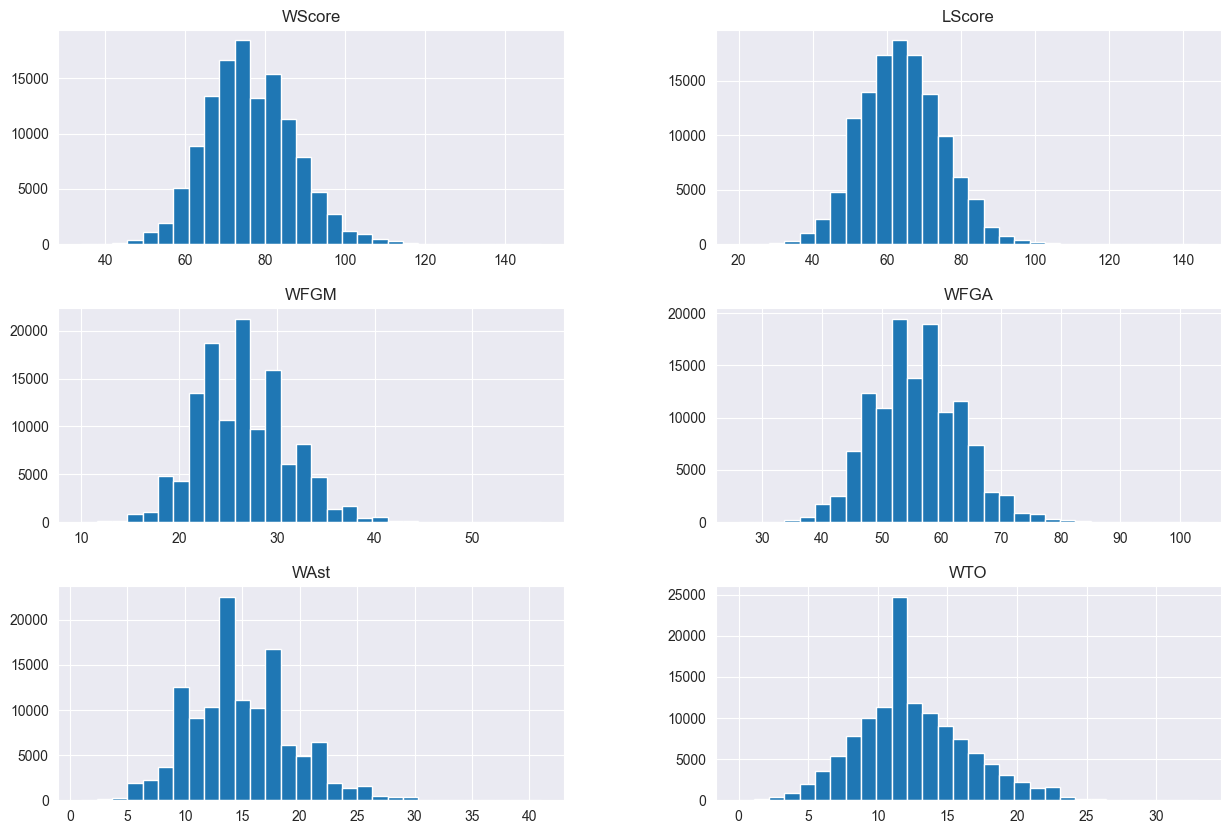

In [62]:
_ = reg_season[['WScore','LScore','WFGM','WFGA','WAst','WTO']].hist(bins = 30, figsize = (15,10))

### Winning margin distribution

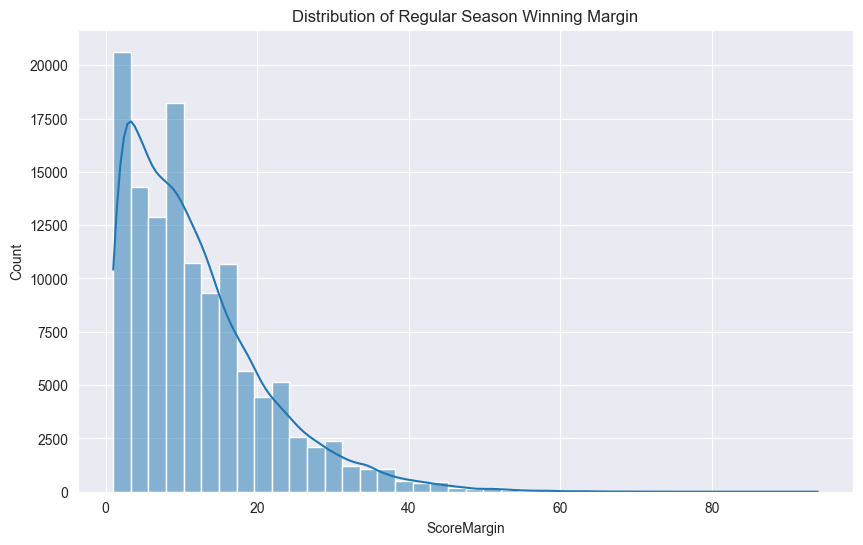

In [63]:
plt.figure(figsize = (10,6))
sns.histplot(reg_season['ScoreMargin'], bins = 40, kde = True)
plt.title('Distribution of Regular Season Winning Margin')
plt.show()

### Home court advantage
who wins more often at home / away / neutral site

Text(0.5, 1.0, 'Winning Team Location (H = Home, A = Away, N = Neutral)')

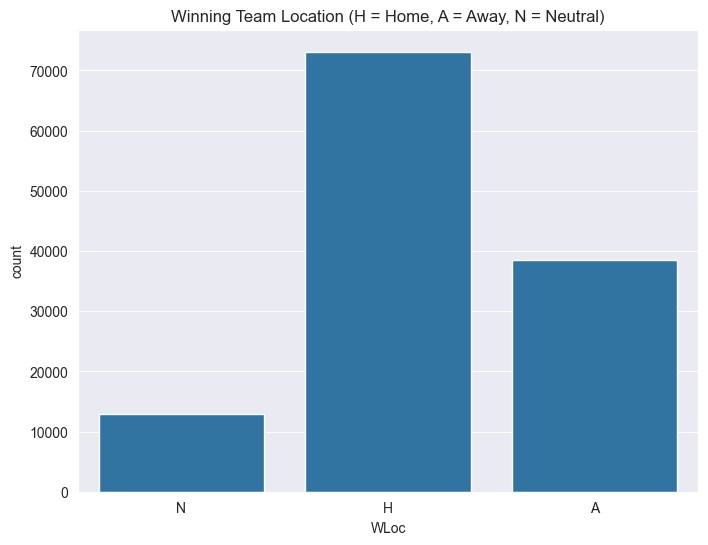

In [46]:
plt.figure(figsize = (8,6))
sns.countplot(x = 'WLoc', data = reg_season)
plt.title('Winning Team Location (H = Home, A = Away, N = Neutral)')
plt.show()

### Stat corralations

<Axes: >

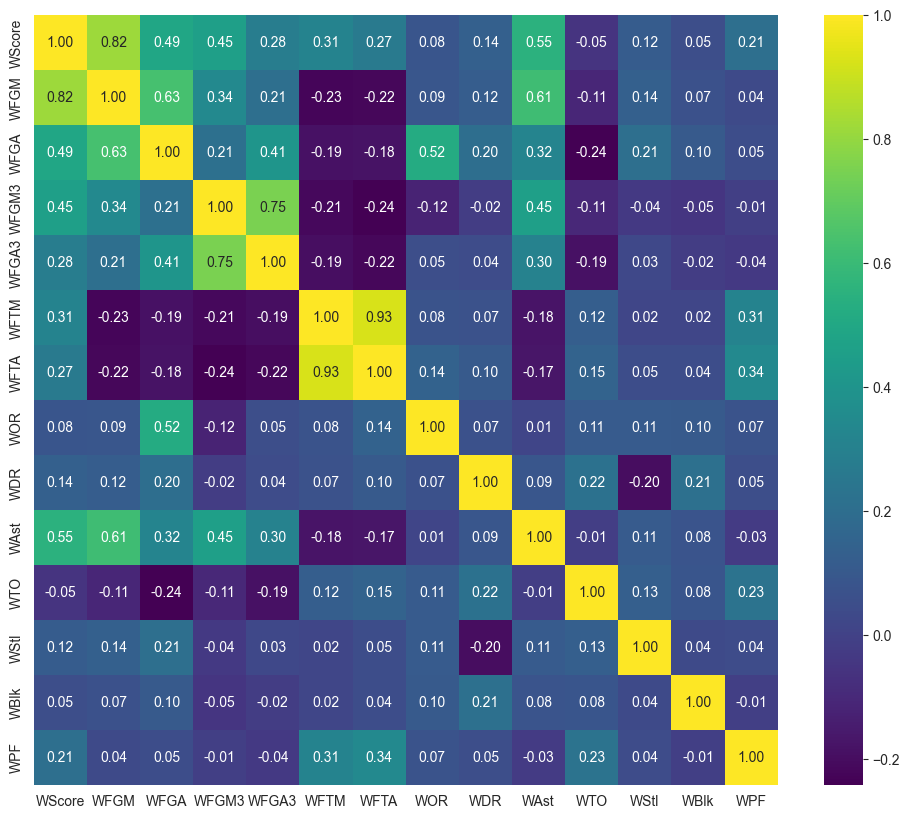

In [47]:
corr = reg_season[['WScore','WFGM','WFGA','WFGM3','WFGA3','WFTM','WFTA',
                    'WOR','WDR','WAst','WTO','WStl','WBlk','WPF']].corr()
plt.figure(figsize = (12,10))
_ = sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'viridis')

### Pairplot on a sample of games 
full dataset is too large to plot cleanly so sample

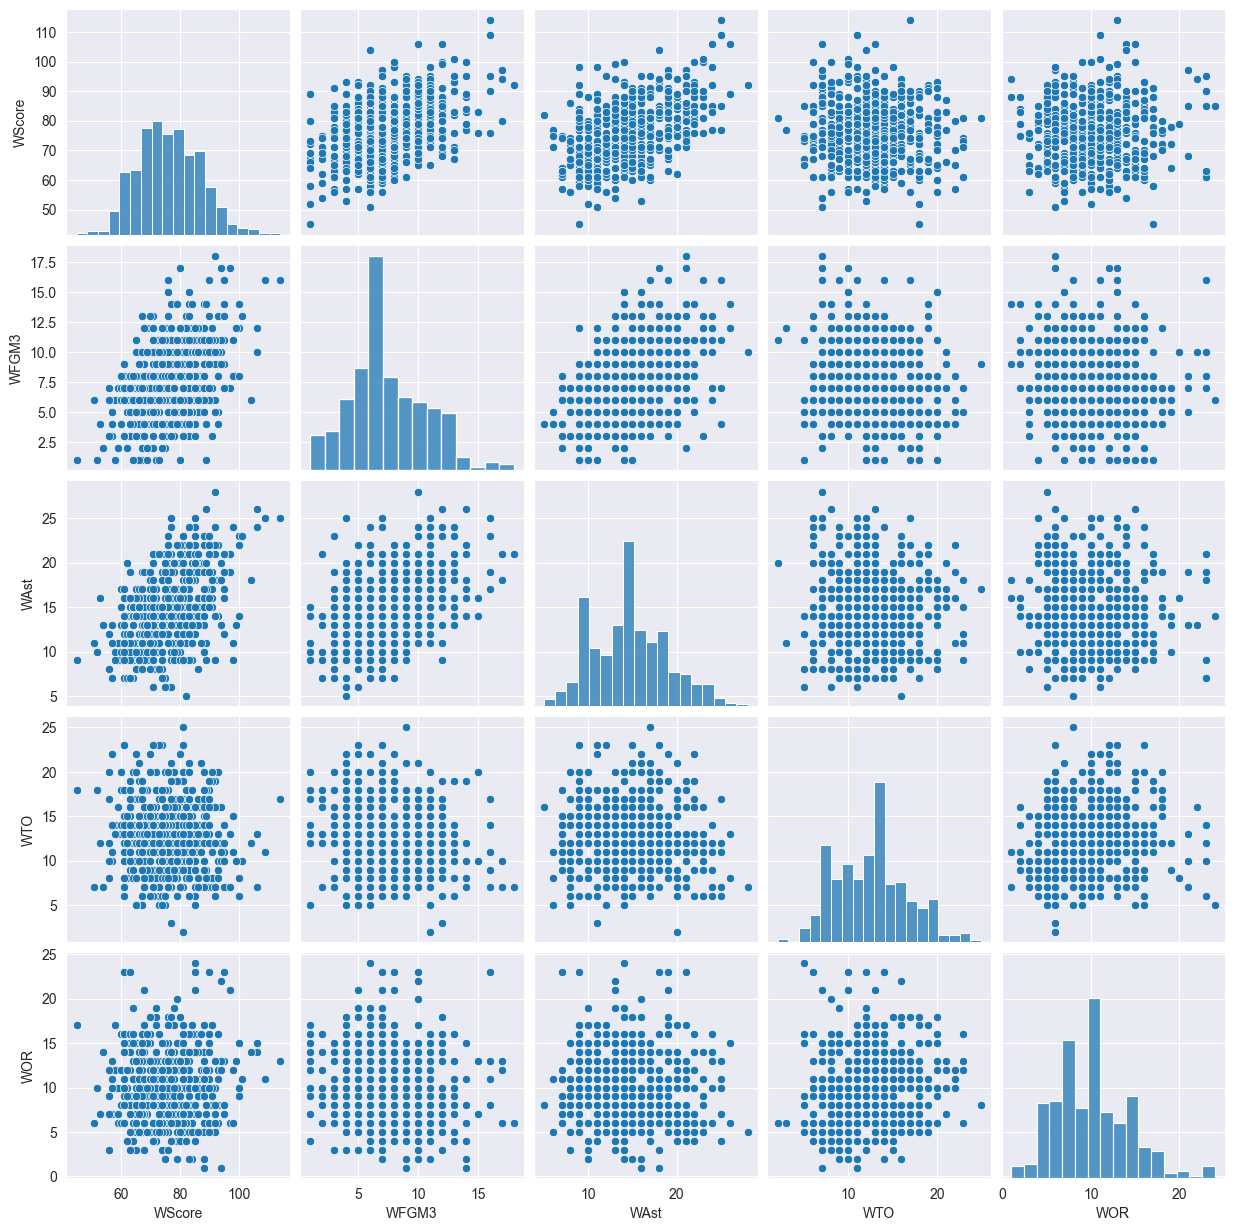

In [48]:
_ = sns.pairplot(reg_season[['WScore','WFGM3','WAst','WTO','WOR']].sample(500, random_state = 42))

## Team Level Statistics
regular season detailed results is built per game, here we aggregate to team level for further analysis

### Game level stats per team
original data is game level statistics, isolate for individual team. the detailed results file lists each game once, split into `W` and `L` prefixed columns. To build a per-team season profile, we reshape this into a long "team-game" format where every row is one team's stat line from one game.

In [49]:
box_cols = ['FGM','FGA','FGM3','FGA3','FTM','FTA','OR','DR','Ast','TO','Stl','Blk','PF']

winners = reg_season[['Season','DayNum','WTeamID','WScore','LTeamID','LScore'] +
                      ['W' + c for c in box_cols]].copy()
winners.columns = ['Season','DayNum','TeamID','Score','OppTeamID','OppScore'] + box_cols
winners['Win'] = 1

losers = reg_season[['Season','DayNum','LTeamID','LScore','WTeamID','WScore'] +
                     ['L' + c for c in box_cols]].copy()
losers.columns = ['Season','DayNum','TeamID','Score','OppTeamID','OppScore'] + box_cols
losers['Win'] = 0

team_games = pd.concat([winners, losers], ignore_index = True)
team_games.head()

,Season,DayNum,TeamID,Score,OppTeamID,OppScore,FGM,FGA,FGM3,FGA3,FTM,FTA,OR,DR,Ast,TO,Stl,Blk,PF,Win
0,2003,10,1104,68,1328,62,27,58,3,14,11,18,14,24,13,23,7,1,22,1
1,2003,10,1272,70,1393,63,26,62,8,20,10,19,15,28,16,13,4,4,18,1
2,2003,11,1266,73,1437,61,24,58,8,18,17,29,17,26,15,10,5,2,25,1
3,2003,11,1296,56,1457,50,18,38,3,9,17,31,6,19,11,12,14,2,18,1
4,2003,11,1400,77,1208,71,30,61,6,14,11,13,17,22,12,14,4,4,20,1


In [50]:
team_games.shape

(249058, 20)

### Season level stats per team
aggregate to one row per team per season

In [51]:
season_stats = team_games.groupby(['Season','TeamID']).agg(
    GamesPlayed = ('Win','count'),
    Wins = ('Win','sum'),
    AvgScore = ('Score','mean'),
    AvgOppScore = ('OppScore','mean'),
    AvgFGM = ('FGM','mean'),
    AvgFGA = ('FGA','mean'),
    AvgFGM3 = ('FGM3','mean'),
    AvgFGA3 = ('FGA3','mean'),
    AvgAst = ('Ast','mean'),
    AvgTO = ('TO','mean'),
    AvgOR = ('OR','mean'),
    AvgDR = ('DR','mean')
).reset_index()

season_stats['WinPct'] = season_stats['Wins'] / season_stats['GamesPlayed']
season_stats['AvgScoreMargin'] = season_stats['AvgScore'] - season_stats['AvgOppScore']
season_stats['FGPct'] = season_stats['AvgFGM'] / season_stats['AvgFGA']
season_stats['FG3Pct'] = season_stats['AvgFGM3'] / season_stats['AvgFGA3']

season_stats.head()

,Season,TeamID,GamesPlayed,Wins,AvgScore,AvgOppScore,AvgFGM,AvgFGA,AvgFGM3,AvgFGA3,AvgAst,AvgTO,AvgOR,AvgDR,WinPct,AvgScoreMargin,FGPct,FG3Pct
0,2003,1102,28,12,57.250000,57.000000,19.142857,39.785714,7.821429,20.821429,13.000000,11.428571,4.178571,16.821429,0.428571,0.250000,0.481149,0.375643
1,2003,1103,27,13,78.777778,78.148148,27.148148,55.851852,5.444444,16.074074,15.222222,12.629630,9.777778,19.925926,0.481481,0.629630,0.486074,0.338710
2,2003,1104,28,17,69.285714,65.000000,24.035714,57.178571,6.357143,19.857143,12.107143,13.285714,13.571429,23.928571,0.607143,4.285714,0.420362,0.320144
3,2003,1105,26,7,71.769231,76.653846,24.384615,61.615385,7.576923,20.769231,14.538462,18.653846,13.500000,23.115385,0.269231,-4.884615,0.395755,0.364815
4,2003,1106,28,13,63.607143,63.750000,23.428571,55.285714,6.107143,17.642857,11.678571,17.035714,12.285714,23.857143,0.464286,-0.142857,0.423773,0.346154


In [52]:
season_stats.describe()

,Season,TeamID,GamesPlayed,Wins,AvgScore,AvgOppScore,AvgFGM,AvgFGA,AvgFGM3,AvgFGA3,AvgAst,AvgTO,AvgOR,AvgDR,WinPct,AvgScoreMargin,FGPct,FG3Pct
count,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000,8346.000000
mean,2014.702013,1285.877067,29.841601,14.920800,70.009578,70.221948,24.638449,56.357893,6.822381,19.905259,13.061686,13.157258,10.311117,23.533919,0.494218,-0.212370,0.437105,0.342050
std,6.907589,105.410156,2.790650,6.166791,5.889036,5.562822,2.181549,3.513006,1.428319,3.654502,1.871230,1.964689,2.057555,1.986469,0.186443,6.635321,0.026234,0.028100
min,2003.000000,1101.000000,4.000000,0.000000,49.240000,50.428571,16.120000,39.785714,1.838710,6.064516,7.518519,7.076923,3.560000,15.357143,0.000000,-33.222222,0.342072,0.246787
25%,2009.000000,1194.000000,29.000000,10.000000,66.032258,66.500000,23.153846,54.111111,5.810268,17.300000,11.766667,11.815657,8.866667,22.185764,0.363636,-4.642143,0.419685,0.323003
50%,2015.000000,1285.000000,30.000000,15.000000,69.967742,70.142857,24.612903,56.426407,6.741935,19.685855,12.933333,13.068966,10.366667,23.484848,0.500000,-0.181818,0.437262,0.341589
75%,2021.000000,1378.000000,32.000000,19.000000,73.895628,73.870968,26.068966,58.620690,7.741935,22.233333,14.275862,14.413793,11.750000,24.820617,0.628571,4.290323,0.454287,0.360682
max,2026.000000,1481.000000,36.000000,34.000000,95.551724,98.206897,34.153846,78.620690,13.250000,40.300000,21.484848,22.321429,17.259259,31.121212,1.000000,23.787879,0.550868,0.450602


### Regular season scoring margin vs to win percentage

Text(0.5, 1.0, 'Win Percentage vs Average Scoring Margin')

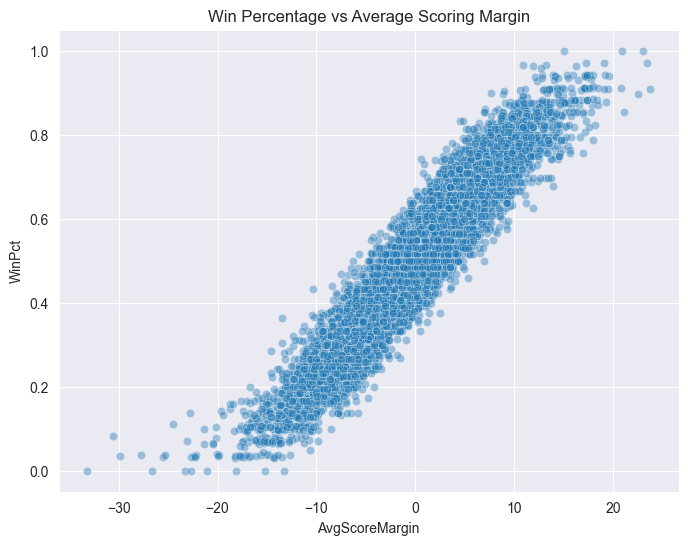

In [53]:
plt.figure(figsize = (8,6))
sns.scatterplot(x = 'AvgScoreMargin', y = 'WinPct', data = season_stats, alpha = 0.4)
plt.title('Win Percentage vs Average Scoring Margin')
plt.show()

### Correlation between key stats at the per team per season level

<Axes: >

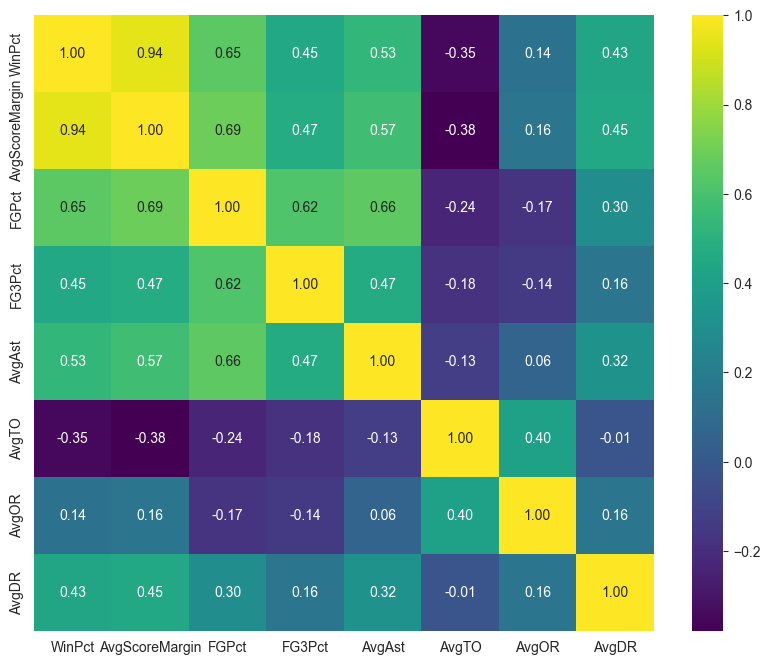

In [54]:
corr2 = season_stats[['WinPct','AvgScoreMargin','FGPct','FG3Pct','AvgAst','AvgTO','AvgOR','AvgDR']].corr()
plt.figure(figsize = (10,8))
_ = sns.heatmap(corr2, annot = True, fmt = '.2f', cmap = 'viridis')

## Season Stats with Tournament Results

In [55]:
print('Tournament seasons:', tourney['Season'].min(), '-', tourney['Season'].max())
tourney.shape

Tournament seasons: 1985 - 2025


(2585, 8)

### Season stats per tournament team
attach each tournament team's regular season profile for that year

In [56]:
tourney_matchups = tourney.merge(season_stats, left_on = ['Season','WTeamID'],
                                  right_on = ['Season','TeamID'], how = 'left')
tourney_matchups = tourney_matchups.merge(season_stats, left_on = ['Season','LTeamID'],
                                           right_on = ['Season','TeamID'], how = 'left',
                                           suffixes = ('_W', '_L'))
tourney_matchups.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,TeamID_W,GamesPlayed_W,...,AvgFGM3_L,AvgFGA3_L,AvgAst_L,AvgTO_L,AvgOR_L,AvgDR_L,WinPct_L,AvgScoreMargin_L,FGPct_L,FG3Pct_L
0,1985,136,1116,63,1234,54,N,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1985,136,1120,59,1345,58,N,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1985,136,1207,68,1250,43,N,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1985,136,1229,58,1425,55,N,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1985,136,1242,49,1325,38,N,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
tourney_matchups.isnull().sum()

Season                 0
DayNum                 0
WTeamID                0
WScore                 0
LTeamID                0
LScore                 0
WLoc                   0
NumOT                  0
TeamID_W            1136
GamesPlayed_W       1136
Wins_W              1136
AvgScore_W          1136
AvgOppScore_W       1136
AvgFGM_W            1136
AvgFGA_W            1136
AvgFGM3_W           1136
AvgFGA3_W           1136
AvgAst_W            1136
AvgTO_W             1136
AvgOR_W             1136
AvgDR_W             1136
WinPct_W            1136
AvgScoreMargin_W    1136
FGPct_W             1136
FG3Pct_W            1136
TeamID_L            1136
GamesPlayed_L       1136
Wins_L              1136
AvgScore_L          1136
AvgOppScore_L       1136
AvgFGM_L            1136
AvgFGA_L            1136
AvgFGM3_L           1136
AvgFGA3_L           1136
AvgAst_L            1136
AvgTO_L             1136
AvgOR_L             1136
AvgDR_L             1136
WinPct_L            1136
AvgScoreMargin_L    1136


### Reg season vs tournament results 
does the team with the better regular season win percentage tend to win the tournament game?

Text(0.5, 0, 'WinPct(winning team) - WinPct(losing team)')

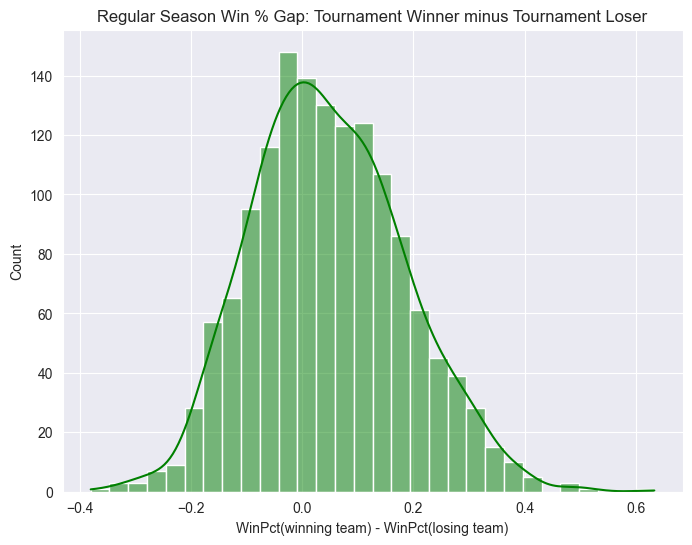

In [58]:
plt.figure(figsize = (8,6))
sns.histplot(tourney_matchups['WinPct_W'] - tourney_matchups['WinPct_L'], bins = 30, kde = True, color = 'g')
plt.title('Regular Season Win % Gap: Tournament Winner minus Tournament Loser')
plt.xlabel('WinPct(winning team) - WinPct(losing team)')
plt.show()

does the team with better scoring margin in the reg season win?

Text(0.5, 1.0, 'Regular Season Scoring Margin Gap: Tournament Winner minus Tournament Loser')

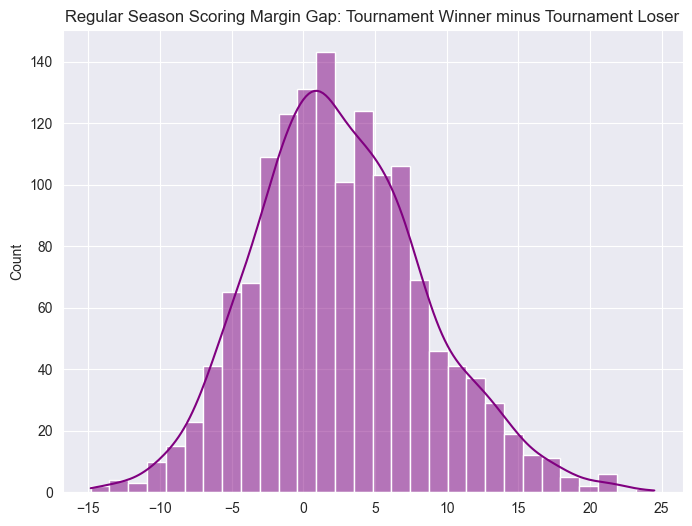

In [65]:
plt.figure(figsize = (8,6))
sns.histplot(tourney_matchups['AvgScoreMargin_W'] - tourney_matchups['AvgScoreMargin_L'], bins = 30, kde = True, color = 'purple')
plt.title('Regular Season Scoring Margin Gap: Tournament Winner minus Tournament Loser')
plt.show()